In [46]:
import numpy as np
import matplotlib.pyplot as plt


## Questão 1



### a)

 Partindo da equação dada no enunciado:
$$Q_v x = \|x\| e_1$$

Substituindo a definição da matriz refletora $Q_v$:
$$(I - \beta v v^*) x = \|x\| e_1$$

Distribuindo o vetor $x$:
$$x - \beta v v^* x = \|x\| e_1$$

Isolando o termo com o vetor $v$:
$$\beta v v^* x = x - \|x\| e_1$$

Como o produto interno $v^* x$ resulta em um escalar, podemos reorganizar a equação agrupando os termos escalares:
$$[\beta (v^* x)] v = x - \|x\| e_1$$

Temos que $\|x\|e_1$ é o vetor cuja primeira coordenada é a norma de $x$ e o resto é 0. Logo, $x - \|x\|e_1$ é a definição do vetor $v$.

Na construção de refletores de Householder, qualquer múltiplo escalar de $v$ gera a mesma matriz ortogonal $Q_v$, desde que $\beta$ seja ajustado proporcionalmente. Portanto, por conveniência, assumimos que a constante é igual a $1$:
$$[\beta(v^* x)] = 1$$
$$v = x - \|x\| e_1$$

A partir da premissa de que a constante é $1$, vamos isolar o escalar $\beta$:
$$\beta (v^* x) = 1 \implies \beta = \frac{1}{v^* x}$$

Substituindo a expressão encontrada para $v$:
$$\beta = \frac{1}{(x - \|x\| e_1)^* x}$$

Fazendo a distributiva no denominador e sabendo que $x^* x = \|x\|^2$ e $\|x\| e_1^* x = \|x\| x_1$:
$$\beta = \frac{1}{\|x\|^2 - \|x\| x_1}$$

Colocando $\|x\|$ em evidência, chegamos à primeira igualdade do $\beta$:
$$\beta = \frac{1}{\|x\|(\|x\| - x_1)}$$

Para encontrar a segunda igualdade, multiplicamos o numerador e o denominador por $(\|x\| + x_1)$:
$$\beta = \frac{1}{\|x\|(\|x\| - x_1)} \cdot \frac{\|x\| + x_1}{\|x\| + x_1} = \frac{\|x\| + x_1}{\|x\|(\|x\|^2 - x_1^2)}$$

O termo $(\|x\|^2 - x_1^2)$ é a norma ao quadrado do vetor subtraindo o quadrado da sua primeira coordenada. Definindo o vetor $y$ como o restante das coordenadas, $y = (x_2, x_3, \dots, x_n)$, temos a relação de que $\|x\|^2 - x_1^2 = \|y\|^2$. 

Substituindo isso no denominador, chegamos à última igualdade pedida:
$$\beta = \frac{\|x\| + x_1}{\|x\| \cdot \|y\|^2}$$

### b)

 Se tomarmos $x_1$ negativo, em um vetor $x$ tal que $|x_1| \gg |x_n|$ para todo $n \ge 2$, teremos nas fórmulas 2 e 3 um elemento $(\|x\| + x_1)$ no numerador. Além disso, teremos o elemento $(\|x\|^2 - x_1^2)$ no denominador da fórmula 2.

Como $\|x\| \approx |x_1|$ (e sendo $x_1$ negativo, $|x_1| = -x_1$), esses elementos resultarão em valores muito próximos de $0$:
$$\|x\| + x_1 \approx (-x_1) + x_1 = 0$$

Essa subtração de valores quase iguais colabora para a perda severa de precisão devido ao cancelamento catastrófico. 

Porém, na primeira fórmula, temos no denominador o elemento $(\|x\| - x_1)$. Como $x_1$ é negativo, essa operação se torna, na prática, uma soma de magnitudes:
$$\|x\| - x_1 \approx (-x_1) - x_1 = -2x_1$$

Sendo $-2x_1$ um número positivo grande, essa formulação evita a subtração de termos próximos, protegendo o cálculo contra a perda de precisão por causa do cancelamento numérico. Portanto, para $x_1 < 0$, a primeira fórmula é a escolha numérica estável.

### c)

In [47]:
def reflector(x):
    """
    Calcula o vetor refletor (v) e o escalar (beta) de Householder para um vetor x.
    O refletor Q = I - beta * v * v^T zera todas as componentes de x, exceto a primeira.
    """
    normax = np.linalg.norm(x)

    # Caso extremo: Se o vetor já for nulo, a reflexão não é necessária.
    # Evita divisão por zero nos cálculos de beta a seguir.
    if normax == 0:
        return x, 0.0
        
    # Constrói o vetor w = ||x||*e1 (vetor com a norma de x na 1ª coordenada e 0 nas demais)
    w = np.zeros(x.size)
    w[0] = normax
    
    # Define a direção inicial do vetor refletor (v = x - ||x||*e1)
    v = x - w

    # --- Análise de Estabilidade Numérica ---
    # A escolha da fórmula para o beta depende do sinal da primeira coordenada (x[0])
    # para blindar o algoritmo contra o cancelamento catastrófico.
    if x[0] < 0:
        # Se x[0] é negativo, o termo (||x|| - x[0]) na verdade soma as magnitudes,
        # o que é uma operação segura e sem perda de dígitos significativos.
        beta = 1 / (normax * (normax - x[0]))

    else:
        # Se x[0] é positivo, usamos a fórmula alternativa para o denominador.
        # Aqui, o termo (||x|| + x[0]) no numerador garante uma soma segura.
        y = x[1:] # Fatiamento: isola as coordenadas de x a partir do segundo elemento
        normay = np.linalg.norm(y)
        
        beta = (normax + x[0]) / (normax * (normay**2))

    return v, beta


### d)

 Para encontrar a matriz Jacobiana $J = \frac{\partial v}{\partial x}$, calculamos as derivadas das partes que compõem o vetor $v = x - \|x\|e_1$:

Para o termo da norma:
$$\frac{\partial (e_1 \|x\|)}{\partial x} = e_1 \frac{\partial \|x\|}{\partial x} = e_1 \frac{x^*}{\|x\|} = \frac{e_1 x^*}{\|x\|}$$

Para o termo do próprio vetor $x$:
$$\frac{\partial x}{\partial x} = I$$

Logo, a derivada de $v$ em relação a $x$ é a subtração dessas partes:
$$J = \frac{\partial v}{\partial x} = \frac{\partial x}{\partial x} - \frac{\partial (e_1 \|x\|)}{\partial x} = I - \frac{e_1 x^*}{\|x\|}$$

Sabemos que o número de condicionamento absoluto é dado pela norma da matriz Jacobiana:
$$K_{abs} = \sup \frac{\|\Delta f\|}{\|\Delta x\|} = \|J\|$$

Para deduzir o limite superior desse condicionamento, aplicamos a desigualdade triangular na norma de $J$:
$$\|J\| = \left\| I - \frac{e_1 x^*}{\|x\|} \right\| \le \|I\| + \left\| \frac{e_1 x^*}{\|x\|} \right\|$$

Sabendo que a norma da matriz Identidade é $\|I\| = 1$ e que a norma induzida do produto externo $e_1 x^*$ é o produto das normas dos vetores individuais:
$$\|J\| \le 1 + \frac{\|e_1\| \cdot \|x\|}{\|x\|} = 1 + (\|e_1\| \cdot 1)$$

Como $e_1$ é um vetor unitário, sua norma é $\|e_1\| = 1$. Substituindo na equação:
$$\|J\| \le 1 + 1 = 2$$

Logo, concluímos que o número de condicionamento absoluto é menor ou igual a 2:
$$K_{abs} = \|J\| \le 2$$

### e)

Primeiramente, retomamos a função implementada na alternativa (c):

```python

def reflector(x):
    normax = np.linalg.norm(x)

    if normax == 0:
        return x, 0
        
    w = np.zeros(x.size)
    w[0] = normax
    v = x - w

    if x[0] < 0:
        beta = 1 / (normax * (normax - x[0]))
    else:
        y = x[1:]
        normay = np.linalg.norm(y)
        beta = (normax + x[0]) / (normax * (normay**2))

    return v, beta

Para que não haja problemas com a promoção automática de tipos (situação em que o Python silenciosamente converte nossas contas para Float64 para não perder precisão), devemos mudar a inicialização do vetor w para que ele herde o tipo do vetor de entrada (dtype=x.dtype) e o retorno inicial do zero para respeitar o mesmo formato, de modo que nosso código fique assim:

In [48]:
def reflector_update(x):
    """
    Calcula o vetor refletor (v) e o escalar (beta) de Householder para um vetor x.
    Adaptado para manter a consistência de tipos (Float32 ou Float64).
    """
    normax = np.linalg.norm(x)

    if normax == 0:
        # Retorna o zero respeitando o tipo de entrada (Float32 ou Float64)
        return x, x.dtype.type(0) 
        
    # Herda o tipo do vetor x para evitar promoção para Float64
    w = np.zeros(x.size, dtype=x.dtype)
    w[0] = normax
    v = x - w

    if x[0] < 0:
        # Constante inteira 1 evita promoção acidental por constantes Float (como 1.0)
        beta = 1 / (normax * (normax - x[0]))
    else:
        y = x[1:] 
        normay = np.linalg.norm(y)
        beta = (normax + x[0]) / (normax * (normay**2))

    return v, beta

Abaixo está o script utilizado para testar a estabilidade da função, forçando o uso de um vetor de 32 bits propenso a erros de arredondamento e comparando-o com o padrão de 64 bits:

In [49]:
# Criando um vetor base propício a erros de arredondamento
vetor_base = [10000.0, 0.1, 0.1]

# Convertendo o vetor para os dois tipos
x64 = np.array(vetor_base, dtype=np.float64)
x32 = np.array(vetor_base, dtype=np.float32)

# Calculando os refletores
v64, beta64 = reflector_update(x64)
v32, beta32 = reflector_update(x32)

print(f"Tipo resultante (esperado Float64): {v64.dtype}")
print(f"Tipo resultante (esperado Float32): {v32.dtype}")
print(f"Vetor V (64 bits): {v64}")
print(f"Vetor V (32 bits): {v32}")

Tipo resultante (esperado Float64): float64
Tipo resultante (esperado Float32): float32
Vetor V (64 bits): [-1.00000034e-06  1.00000000e-01  1.00000000e-01]
Vetor V (32 bits): [0.  0.1 0.1]


### f)

Para que o refletor de Householder $Q_v = I - \beta v v^*$ seja uma matriz ortogonal simétrica, a constante escalar $\beta$ deve satisfazer a relação geral:
$$\beta = \frac{2}{\|v\|^2} = \frac{2}{v^* v}$$

A grande vantagem de calcular $\beta$ exclusivamente a partir do vetor $v$ é que a operação $\|v\|^2$ consiste apenas na soma de quadrados (termos estritamente positivos). Como não há subtração de grandezas, essa formulação é naturalmente imune ao cancelamento catastrófico.

Abaixo, implementamos a função `calc_beta(v)` tomando o cuidado de manter a consistência de tipos (Float32/Float64) ao utilizar a constante `2`:

In [50]:
def calc_beta(v):
    """
    Calcula o parâmetro beta do refletor de Householder 
    diretamente a partir do vetor refletor v.
    """
    # Calcula a norma ao quadrado (produto interno de v por v)
    norm_v_sq = np.dot(v, v)
    
    if norm_v_sq == 0:
        return v.dtype.type(0)
        
    # Usa a constante '2' no mesmo tipo do vetor para evitar promoção
    dois = v.dtype.type(2)
    return dois / norm_v_sq

Para validar a estabilidade, rodamos um script de teste comparando esta nova função com a função reflector_update(x) feita anteriormente, utilizando vetores propensos a erros de arredondamento:

In [51]:
# --- SCRIPT DE TESTE COMPARATIVO ---
vetor_base = [10000.0, 0.1, 0.1]

x64 = np.array(vetor_base, dtype=np.float64)
x32 = np.array(vetor_base, dtype=np.float32)

# Calculamos usando a função da letra (e) - Baseada em x
v64, beta_antigo64 = reflector_update(x64)
v32, beta_antigo32 = reflector_update(x32)

# Calculamos usando a nova função - Baseada apenas em v
beta_novo64 = calc_beta(v64)
beta_novo32 = calc_beta(v32)

print("--- RESULTADOS FLOAT 64 BITS ---")
print(f"Beta calculado por x: {beta_antigo64}")
print(f"Beta calculado por v: {beta_novo64}")

print("\n--- RESULTADOS FLOAT 32 BITS ---")
print(f"Beta calculado por x: {beta_antigo32}")
print(f"Beta calculado por v: {beta_novo32}")

--- RESULTADOS FLOAT 64 BITS ---
Beta calculado por x: 99.99999999499997
Beta calculado por v: 99.99999999499998

--- RESULTADOS FLOAT 32 BITS ---
Beta calculado por x: 99.99999237060547
Beta calculado por v: 99.99999237060547


### g)

Sabemos que a primeira coordenada do vetor refletor é dada por:
$$v_1 = x_1 - \|x\|$$

Quando o vetor $x$ está quase perfeitamente alinhado com o eixo $e_1$ (e $x_1 > 0$), as coordenadas $(x_2, \dots, x_n)$ são próximas de zero. Logo, $\|x\| \approx x_1$. Nesse caso, o cálculo de $v_1$ envolve subtrair dois números positivos quase idênticos, o que gera cancelamento catastrófico.

Para verificar a instabilidade, podemos analisar o número de condicionamento relativo ($\kappa_{rel}$) dessa operação em relação a $x$:
$$\kappa_{rel} = \frac{\|\nabla v_1\| \cdot \|x\|}{|v_1|}$$

O gradiente de $v_1(x) = x_1 - \|x\|$ é:
$$\nabla v_1 = e_1 - \frac{x}{\|x\|}$$

A norma desse gradiente ao quadrado é:
$$\|\nabla v_1\|^2 = \left(1 - \frac{x_1}{\|x\|}\right)^2 + \sum_{i=2}^n \left(\frac{x_i}{\|x\|}\right)^2 = 1 - \frac{2x_1}{\|x\|} + \frac{x_1^2 + \|y\|^2}{\|x\|^2}$$
Como $x_1^2 + \|y\|^2 = \|x\|^2$, a fração final é $1$, resultando em:
$$\|\nabla v_1\|^2 = 2 - \frac{2x_1}{\|x\|} = \frac{2(\|x\| - x_1)}{\|x\|} \implies \|\nabla v_1\| = \frac{\sqrt{2(\|x\| - x_1)}}{\sqrt{\|x\|}}$$

Substituindo $\|\nabla v_1\|$ e $|v_1| = \|x\| - x_1$ na fórmula do condicionamento:
$$\kappa_{rel} = \frac{\sqrt{2(\|x\| - x_1)}}{\sqrt{\|x\|}} \cdot \frac{\|x\|}{\|x\| - x_1} = \frac{\sqrt{2\|x\|}}{\sqrt{\|x\| - x_1}}$$



Quando $x$ tende a se alinhar com $e_1$, temos que $x_1 \to \|x\|$, o que faz o denominador tender a zero. Portanto, $\kappa_{rel} \to \infty$, mostrando que o problema é mal-condicionado.


Para obter uma formulação estável, podemos multiplicar e dividir a equação original de $v_1$ pelo seu conjugado $(\|x\| + x_1)$:$$v_1 = \frac{(x_1 - \|x\|)(x_1 + \|x\|)}{x_1 + \|x\|} = \frac{x_1^2 - \|x\|^2}{x_1 + \|x\|}$$Como $\|x\|^2 = x_1^2 + \|y\|^2$, onde $y = (x_2, \dots, x_n)$, o numerador se simplifica para $-\|y\|^2$:$$v_1 = \frac{-\|y\|^2}{x_1 + \|x\|}$$Essa nova expressão evita o cancelamento numérico. Como assumimos $x_1 > 0$ (e a norma é sempre positiva), o denominador agora é estritamente uma soma de termos positivos, e o numerador é apenas a soma de quadrados. Dessa forma, o cálculo de $v_1$ torna-se estável

## Questão 2 


### a)

In [52]:
def apply_reflector(v, beta, b):
    """Função que calcula Qb, onde Q = I - beta * vv* 

    Args:
        v (_type_): vetor que define a transformação de household
        beta (_type_): parâmetro que regula a transformação para manter Q ortogonal
        b (_type_): Vetor que estamos projetando 
    """
    n = len(v)                                          # Atribuição custo 1

    if len(b) < n:                                      # Comparação custo 1
        raise ValueError("Vetor no tamanho inválido")

    results = b.copy()                                  # Copia custo m = len(b)
    tail = results[-n:]                                 # Copia custo n = len(v)
    results[-n:] = tail - beta * (v.T @ tail) * v       # Produto interno + soma + multiplicação 4n 
    return results                                      # Complexibilidade final Max(m,n)

### b)

A aplicação do refletor é realizada sem formar explicitamente a matriz Q. Utilizando a identidade

$$Qb=b−β(vTb)v$$

o custo é dominado por um produto interno e operações vetoriais, resultando em complexidade O(n), onde n é a dimensão do vetor de Householder. A implementação apresentada utiliza uma cópia do vetor de entrada para evitar modificações in-place, o que adiciona um custo O(m), onde m é a dimensão de b. Caso seja permitida a modificação direta do vetor de entrada, a implementação mantém complexidade O(n).

Para verificar a corretude da implementação, testamos as propriedades matemáticas que um refletor de Householder $Q = I - \beta v v^T$ deve satisfazer.

Teste 1 — Comparação com a matriz explícita: construímos $Q = I - \beta vv^T$ e comparamos $apply\_reflector(v, \beta, b)$ com $Qb$. A diferença deve ficar na ordem da precisão numérica ($\sim 10^{-15}$).

In [53]:
n = 5

v = np.random.randn(n)
beta = 2 / (v @ v)

b = np.random.randn(n)

Q = np.eye(n) - beta * np.outer(v, v)

r1 = apply_reflector(v, beta, b)
r2 = Q @ b

print(f"||apply_reflector(v, beta, b) - Q@b|| = {np.linalg.norm(r1 - r2)}")

||apply_reflector(v, beta, b) - Q@b|| = 2.482534153247273e-16


Teste 2 — Preservação da norma: como $Q$ é ortogonal, $\|Qb\| = \|b\|$.

In [54]:
b = np.random.randn(10)

qb = apply_reflector(v, beta, b)

print(f"||b||  = {np.linalg.norm(b)}")
print(f"||Qb|| = {np.linalg.norm(qb)}")

||b||  = 3.4205138608396903
||Qb|| = 3.4205138608396903


Teste 3 — Aplicar duas vezes: um refletor satisfaz $Q^2 = I$, ou seja, $Q(Qb) = b$. Este é um dos testes mais sensíveis a erros de implementação.

In [55]:
b = np.random.randn(n)

qb = apply_reflector(v, beta, b)
qqb = apply_reflector(v, beta, qb)

print(f"||Q(Qb) - b|| = {np.linalg.norm(qqb - b)}")

||Q(Qb) - b|| = 0.0


Teste 4 — Vetor alinhado com $v$: sabemos que $Qv = -v$ quando $\beta = \frac{2}{v^Tv}$.

In [56]:
v_teste = np.random.randn(5)
beta_teste = 2 / (v_teste @ v_teste)

print(f"Q@v  = {apply_reflector(v_teste, beta_teste, v_teste)}")
print(f"-v   = {-v_teste}")

Q@v  = [-1.71794824  1.64586891  1.72350463 -1.67818728 -0.62798521]
-v   = [-1.71794824  1.64586891  1.72350463 -1.67818728 -0.62798521]


Teste 5 — Vetor ortogonal a $v$: se $v^Tb = 0$, então $Qb = b - \beta(v^Tb)v = b$, ou seja, o refletor não altera $b$.

In [57]:
v_teste = np.array([1., 0., 0.])
beta_teste = 2.
b_teste = np.array([0., 5., 2.])

print(f"Q@b = {apply_reflector(v_teste, beta_teste, b_teste)}")
print(f"b   = {b_teste}")

Q@b = [0. 5. 2.]
b   = [0. 5. 2.]


Os cinco testes confirmam que `apply_reflector` implementa corretamente a transformação de Householder: o resultado coincide com a aplicação direta da matriz $Q$ (Teste 1), preserva a norma do vetor (Teste 2), é sua própria inversa ($Q^2 = I$, Teste 3), reflete corretamente o vetor $v$ para $-v$ (Teste 4) e mantém inalterados vetores ortogonais a $v$ (Teste 5). Em todos os casos os erros ficam na ordem de $10^{-15}$ a $10^{-16}$, compatível com a precisão de ponto flutuante.

### c) 


In [58]:
def apply_reflector_left(v, beta, A): 
    """Função que calcula QA, onde Q = I - beta * vv* 

    Args:
        v (_type_): vetor que define a transformação de household
        beta (_type_): parâmetro que regula a transformação para manter Q ortogonal
        A (_type_): Matriz que estamos projetando pela esquerda
    """
    n = len(v) 
    
    if A.shape[0] < n:
        raise ValueError("Dados em um formato inválido")
                                            
    results = A.copy()                              
    block = results[-n:, :]                                
    results[-n:, :] = block - beta * np.outer(v, v.T @ block)
    return results      


### d)

In [59]:
def apply_reflector_right(v, beta, A): 
    """Função que calcula AQ, onde Q = I - beta * vv* 

    Args:
        v (_type_): vetor que define a transformação de household
        beta (_type_): parâmetro que regula a transformação para manter Q ortogonal
        A (_type_): Matriz que estamos projetando pela direita
    """
    n = len(v)
    
    if A.shape[1] < n: 
        raise ValueError("Dados em um formato inválido")
                                             
    results = A.copy()                              
    block = results[:, -n:]                                
    results[:, -n:] = block - beta * np.outer(block @ v, v)
    return results      

### e)


In [60]:
def householder_vector(x):
    sigma = np.linalg.norm(x)

    if sigma == 0:
        return np.zeros_like(x), 0.0

    alpha = -np.sign(x[0]) * sigma

    if x[0] == 0:
        alpha = -sigma

    v = x.copy()
    v[0] -= alpha
    beta = 2.0 / (v @ v)
    return v, beta


def to_hessenberg(A):
    n = A.shape[0]
    H = A.astype(float).copy()
    reflectors = []

    for k in range(n-2):

        x = H[k+1:, k]
        v, beta = householder_vector(x)

        reflectors.append((v, beta))

        H[k+1:, k:] = apply_reflector_left(v, beta, H[k+1:, k:])
        H[:, k+1:] = apply_reflector_right(v, beta, H[:, k+1:])

    return reflectors, H

def refletores_to_Q(reflectors, n): 
    Q = np.eye(n)

    for k, (v, beta) in enumerate(reflectors):

        Qi = np.eye(n)

        Qi[k+1:, k+1:] -= beta * np.outer(v, v)

        Q = Q @ Qi

    return Q


### f)

Para validar `to_hessenberg`, verificamos numericamente duas propriedades que devem valer (a menos de erro de arredondamento):

- **Erro de fatoração**: $\|A - QHQ^T\|$, que mede se a fatoração reconstrói $A$.
- **Erro de ortogonalidade**: $\|Q^TQ - I\|$, que mede se $Q$ é de fato ortogonal.

Testamos para matrizes aleatórias (não simétricas) e simétricas, com $n \in \{2, 10, 100\}$, totalizando 6 casos.

In [61]:
# Validação de to_hessenberg: erro de fatoração e erro de ortogonalidade
np.random.seed(0)

for n in [2, 10, 100]:
    for simetrica in [False, True]:
        A = np.random.randn(n, n)
        if simetrica:
            A = (A + A.T) / 2

        reflectors, H = to_hessenberg(A)
        Q = refletores_to_Q(reflectors, n)

        erro_fatorizacao = np.linalg.norm(A - Q @ H @ Q.T)
        erro_ortogonalidade = np.linalg.norm(Q.T @ Q - np.eye(n))

        tipo = "simétrica" if simetrica else "não simétrica"
        print(f"n={n:3d} ({tipo}): erro fatoração = {erro_fatorizacao:.3e} | erro ortogonalidade = {erro_ortogonalidade:.3e}")

n=  2 (não simétrica): erro fatoração = 0.000e+00 | erro ortogonalidade = 0.000e+00
n=  2 (simétrica): erro fatoração = 0.000e+00 | erro ortogonalidade = 0.000e+00
n= 10 (não simétrica): erro fatoração = 9.681e-15 | erro ortogonalidade = 1.872e-15
n= 10 (simétrica): erro fatoração = 3.759e-15 | erro ortogonalidade = 1.495e-15
n=100 (não simétrica): erro fatoração = 2.560e-13 | erro ortogonalidade = 2.970e-14


n=100 (simétrica): erro fatoração = 1.608e-13 | erro ortogonalidade = 2.916e-14


Em todos os seis casos, ambos os erros ficam na ordem de $10^{-14}$ a $10^{-16}$ para $n=2$ e $10$, e em torno de $10^{-13}$ a $10^{-14}$ para $n=100$ — compatível com erro de arredondamento de ponto flutuante, confirmando que $A = QHQ^T$ e que $Q$ é ortogonal.

Além disso, vale observar que, quando $A$ é simétrica, $H$ é simultaneamente Hessenberg superior e simétrica ($H = Q^TAQ$ preserva a simetria), e uma matriz Hessenberg superior simétrica é necessariamente **tridiagonal**. Já no caso não simétrico, $H$ é Hessenberg superior "cheia", com entradas não nulas também acima da subdiagonal.

## Questão 3


### a) 


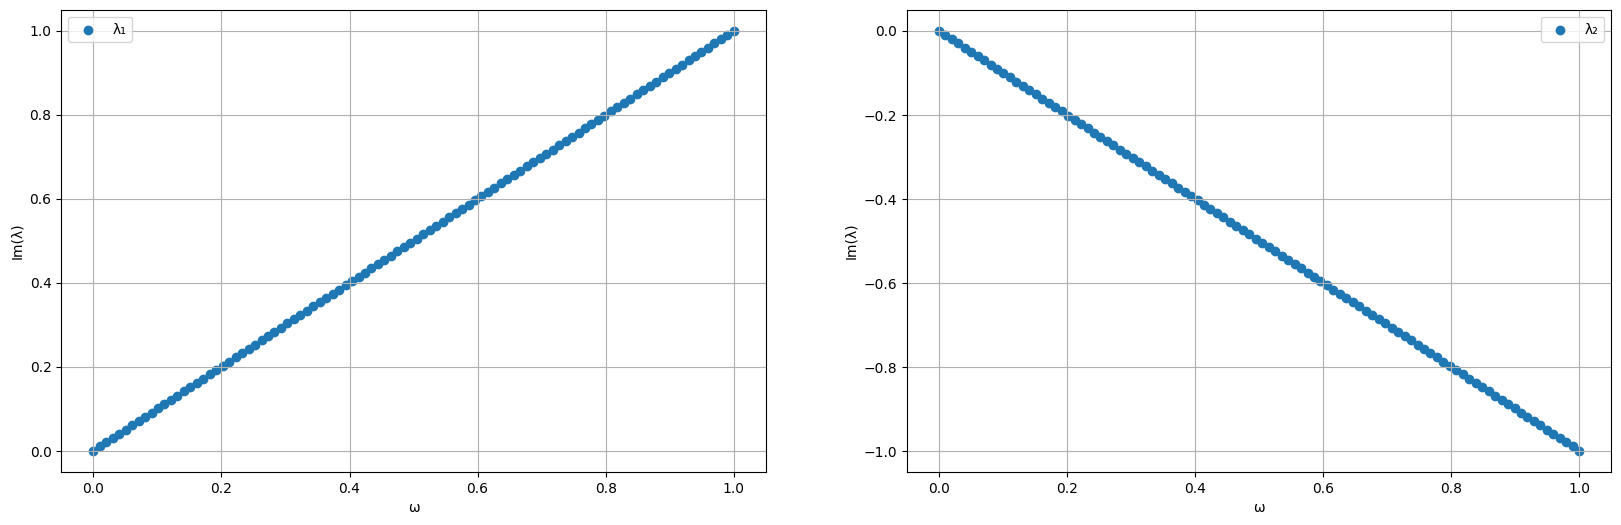

In [115]:
w_s = np.linspace(0, 1, 100)
autovalores1 =[]
autovalores2 = []
for w in w_s:
    A = [[0, 1], [-(w**2), 0]]

    val, vec = np.linalg.eig(A)
    
    autovalores1.append(val[0])
    autovalores2.append(val[1])
    

fig, axs = plt.subplots(1, 2, figsize=(20, 6))

dados = [(autovalores1, "λ₁"), (autovalores2, "λ₂")]

for ax, (autovalores, nome) in zip(axs, dados):

    
    ax.scatter(w_s, np.imag(autovalores), label=nome)
    ax.set_xlabel("ω")
    ax.set_ylabel("Im(λ)")
    ax.grid(True)
    ax.legend()

plt.show()

    

Observando os gráficos gerados, notamos que conforme $\omega$ se aproxima de zero, as linhas convergem para o eixo horizontal. Matematicamente, isso representa um duplo colapso:

1. Autovalores: $\lambda_1$ e $\lambda_2$ convergem para zero. A matriz passa a ter um único autovalor nulo com multiplicidade algébrica 2.
2. Autovetores: A componente imaginária de $v_1$ e $v_2$ desaparece, e ambos convergem para o mesmo vetor real $\begin{bmatrix} 1 \\ 0 \end{bmatrix}$.

Como os dois autovetores colapsam para a mesma direção, eles perdem a independência linear (a multiplicidade geométrica do autovalor 0 é apenas 1). Consequentemente, no limite $\omega \to 0^+$, a matriz $A(0) = \begin{bmatrix} 0 & 1 \\ 0 & 0 \end{bmatrix}$ deixa de ser diagonalizável, tornando-se uma matriz defeituosa (especificamente, uma matriz nilpotente, pois $A(0)^2 = 0$).

### b) 

C:\Users\gabri\AppData\Local\Temp\ipykernel_14340\818884152.py:9: RuntimeWarning: divide by zero encountered in scalar divide
  condicionamento = S.max() / S.min()


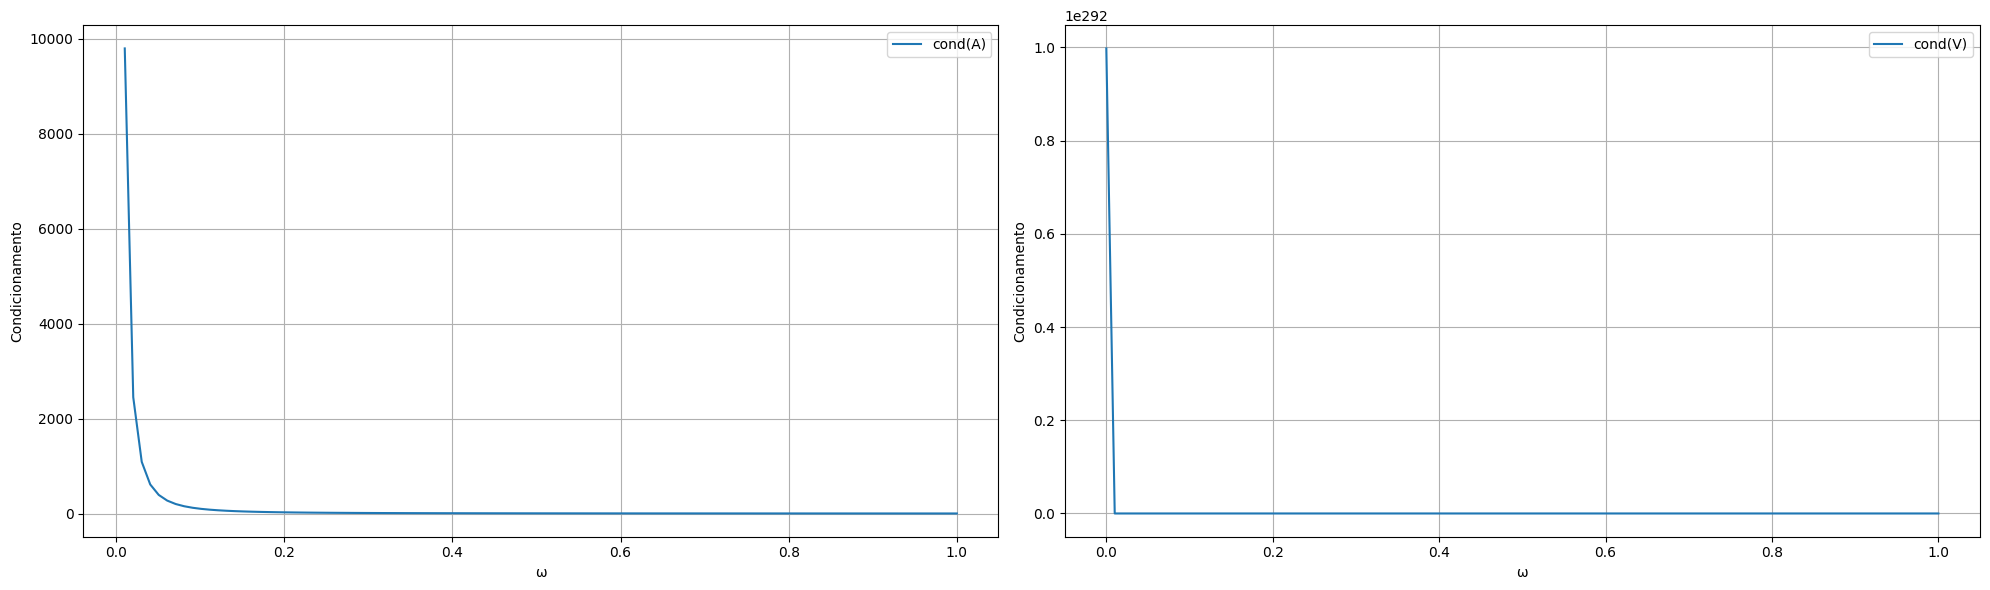

In [125]:
w_s = np.linspace(0, 1, 100)

cond = []
cond_vec = []
for w in w_s:
    A = [[0, 1], [-(w**2), 0]]

    U, S, Vh = np.linalg.svd(A)
    condicionamento = S.max() / S.min()
    cond.append(condicionamento)

    val, vec = np.linalg.eig(A)
    condicionamento = np.linalg.cond(vec)
    cond_vec.append(condicionamento)

fig, axs = plt.subplots(1, 2, figsize=(20, 6))

dados = [(cond, 'cond(A)'), (cond_vec, 'cond(V)')]

for ax, (serie, nome) in zip(axs, dados):
    ax.plot(w_s, serie, label=nome)
    ax.set_xlabel('ω')
    ax.set_ylabel('Condicionamento')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

### c)


Temos que $$A(\omega) = \begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix}$$ Desse modo,

$$
 A(\omega)^2 = \begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix} \begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix} = \begin{bmatrix} 0 - \omega^2 & 0 + 0 \\ 0 + 0 & -\omega^2 + 0 \end{bmatrix} = \begin{bmatrix} -\omega^2 & 0 \\ 0 & -\omega^2 \end{bmatrix}
$$

$$
= -\omega^2 \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix} = -\omega^2 I
$$

A definição da exponencial de uma matriz é dada pela sua expansão em série de Taylor:
$$e^{tA} = \sum_{k=0}^{\infty} \frac{(tA)^k}{k!} = I + tA + \frac{t^2}{2!}A^2 + \frac{t^3}{3!}A^3 + \frac{t^4}{4!}A^4 + \dots$$

Como já mostramos que $A^2 = -\omega^2 I$, podemos deduzir o comportamento de todas as potências superiores de $A$:
* Potências pares: $A^{2k} = (-\omega^2 I)^k = (-1)^k \omega^{2k} I$
* Potências ímpares: $A^{2k+1} = A^{2k} \cdot A = (-1)^k \omega^{2k} A$

Podemos então separar a série de Taylor em duas somas, uma para os termos de índice par e outra para os termos de índice ímpar:
$$e^{tA} = \left( \sum_{k=0}^{\infty} \frac{t^{2k}}{(2k)!} A^{2k} \right) + \left( \sum_{k=0}^{\infty} \frac{t^{2k+1}}{(2k+1)!} A^{2k+1} \right)$$

Substituindo as potências que encontramos:
$$e^{tA} = \left( \sum_{k=0}^{\infty} \frac{(-1)^k t^{2k} \omega^{2k}}{(2k)!} \right) I + \left( \sum_{k=0}^{\infty} \frac{(-1)^k t^{2k+1} \omega^{2k}}{(2k+1)!} \right) A(\omega)$$

Na primeira soma, temos exatamente a série de Taylor da função cosseno: $\cos(\omega t)$.
Na segunda soma, os termos estão quase no formato da série do seno, mas falta um $\omega$ no numerador do expoente. Para consertar isso, multiplicamos e dividimos o termo por $\omega$:
$$e^{tA} = \cos(\omega t) I + \frac{1}{\omega} \left( \sum_{k=0}^{\infty} \frac{(-1)^k (\omega t)^{2k+1}}{(2k+1)!} \right) A(\omega)$$

Reconhecendo a série do seno entre os parênteses, chegamos à fórmula final desejada:
$$e^{tA(\omega)} = \cos(\omega t)I + \frac{\sin(\omega t)}{\omega} A(\omega)$$

Verificação do Limite para $\omega \to 0^+$

Aplicamos o limite na fórmula fechada deduzida:
$$\lim_{\omega \to 0^+} e^{tA(\omega)} = \lim_{\omega \to 0^+} \left( \cos(\omega t)I + \frac{\sin(\omega t)}{\omega} A(\omega) \right)$$

Sabemos que $\lim_{\omega \to 0^+} \cos(\omega t) = 1$. 
Para o segundo termo, usamos o limite trigonométrico fundamental para obter $\lim_{\omega \to 0^+} \frac{\sin(\omega t)}{\omega} = t$. E como $A(\omega) \to A(0)$, o limite nos dá:
$$I + t A(0)$$

Agora, vamos calcular $e^{tA(0)}$ diretamente pela série de Taylor. Sendo $A(0) = \begin{bmatrix} 0 & 1 \\ 0 & 0 \end{bmatrix}$, notamos que ela é uma matriz nilpotente, onde $A(0)^2 = 0$.
Portanto, a série de Taylor trunca logo no segundo termo:
$$e^{tA(0)} = I + tA(0) + \frac{t^2}{2!}(0) + \dots = I + tA(0)$$

Como os dois resultados são idênticos, o limite esta verificado!

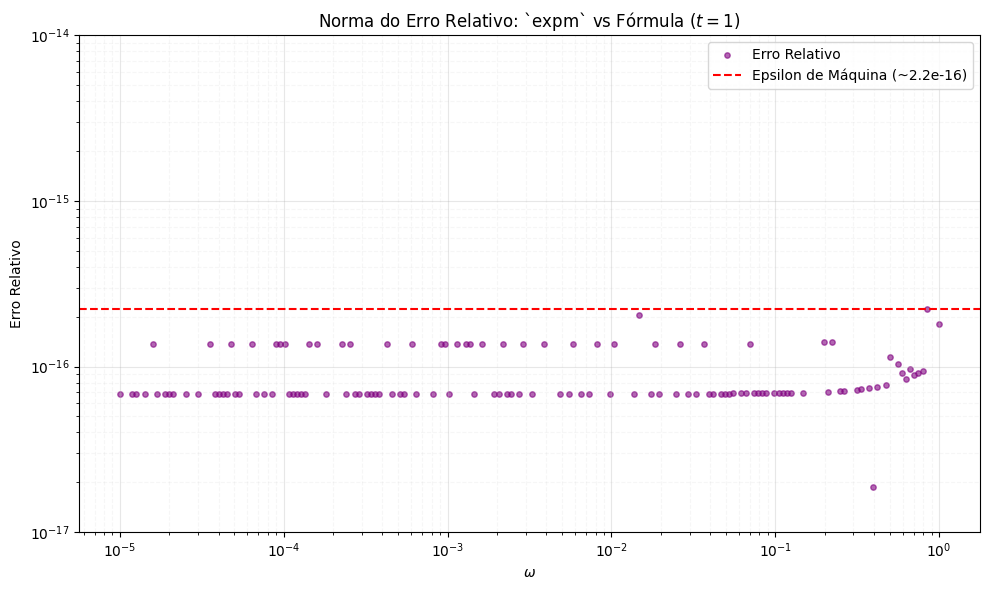

Erro relativo máximo observado: 2.23e-16


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

t = 1.0
omegas = np.logspace(-5, 0, 200)

erros_relativos = []

for w in omegas:
    A_w = np.array([[0, 1], [-w**2, 0]])
    
    # Exponencial computada via SciPy
    exp_calc = expm(t * A_w)
    
    # Exponencial computada pela fórmula deduzida
    exp_formula = np.cos(w * t) * np.eye(2) + (np.sin(w * t) / w) * A_w
    
    # Cálculo do erro relativo (Norma 2)
    norma_erro = np.linalg.norm(exp_calc - exp_formula, ord=2)
    norma_referencia = np.linalg.norm(exp_calc, ord=2)
    
    erro_rel = norma_erro / norma_referencia
    erros_relativos.append(erro_rel)

fig, ax = plt.subplots(figsize=(10, 6))

# Plotando os erros como dispersão devido à natureza do ruído numérico
ax.scatter(omegas, erros_relativos, color='purple', alpha=0.6, s=15, label='Erro Relativo')

# Linha de referência para a precisão de máquina
eps_maquina = np.finfo(float).eps
ax.axhline(y=eps_maquina, color='red', linestyle='--', linewidth=1.5, label=f'Epsilon de Máquina (~{eps_maquina:.1e})')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-17, 1e-14)

ax.set_title(r'Norma do Erro Relativo: `expm` vs Fórmula ($t=1$)')
ax.set_xlabel(r'$\omega$')
ax.set_ylabel('Erro Relativo')
ax.grid(True, which="major", ls="-", alpha=0.3)
ax.grid(True, which="minor", ls="--", alpha=0.1)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

print(f"Erro relativo máximo observado: {max(erros_relativos):.2e}")

Ao analisarmos o gráfico de dispersão do erro relativo, observamos dois comportamentos fundamentais que validam a nossa dedução:

1. Ordem de Grandeza: O erro máximo orbita a casa de $10^{-16}$, coincidindo exatamente com o Epsilon de Máquina do formato Float64 ($\approx 2.22 \times 10^{-16}$). 
2. Quantização do Erro: Os pontos não formam uma nuvem aleatória contínua, mas sim faixas horizontais bem definidas. Esse fenômeno ocorre devido à quantização do erro de ponto flutuante. Como o computador não tem memória para representar reais perfeitamente, o resto da subtração das matrizes assume "degraus" discretos de arredondamento (como $1\epsilon, \sqrt{2}\epsilon, 2\epsilon$).

Conclusão: O fato do erro permanecer estagnado no piso do epsilon de máquina e apresentar o comportamento discreto de quantização prova que a matriz gerada pela nossa dedução de Taylor e a matriz gerada pela aproximação algorítmica do SciPy (expm) são analiticamente idênticas. A diferença visualizada no gráfico não é uma falha da fórmula, mas apenas o limite físico absoluto da precisão do computador.